# Explainability: Stress Level Prediction (Regression)

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from pytorch_tabnet.tab_model import TabNetRegressor
warnings.filterwarnings('ignore')
shap.initjs()

# 1. Load Data
df = pd.read_csv('data/developer_burnout_dataset_7000.csv')
df.dropna(subset=['stress_level', 'burnout_level'], inplace=True)
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)
    
X = df.drop(columns=['stress_level', 'burnout_level'])
y = df['stress_level']
feature_names = X.columns

# 2. Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

c:\Users\theom\AppData\Local\r-miniconda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Random Forest Regressor

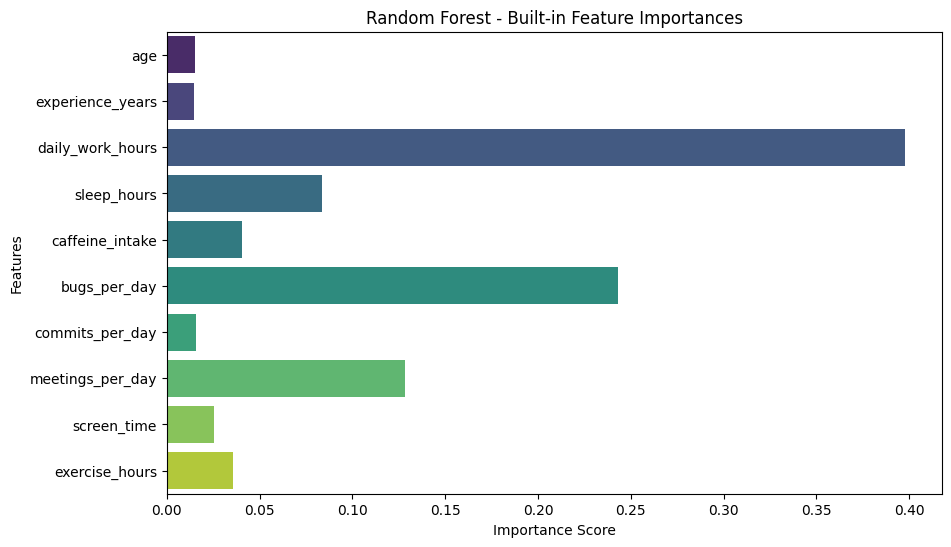

In [2]:
rf_model = joblib.load('random_forest/random_forest_regressor_optimized.pkl')

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_model.feature_importances_, y=feature_names, palette="viridis")
plt.title("Random Forest - Built-in Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

## 2. Support Vector Regressor (SVR)

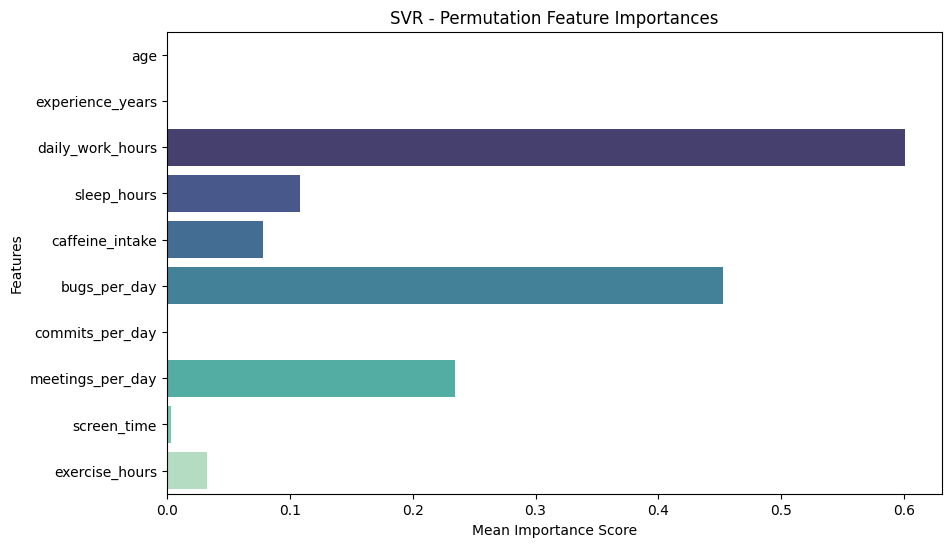

Calculating SHAP values for SVR... (This may take a moment)


100%|██████████| 300/300 [47:31<00:00,  9.50s/it]


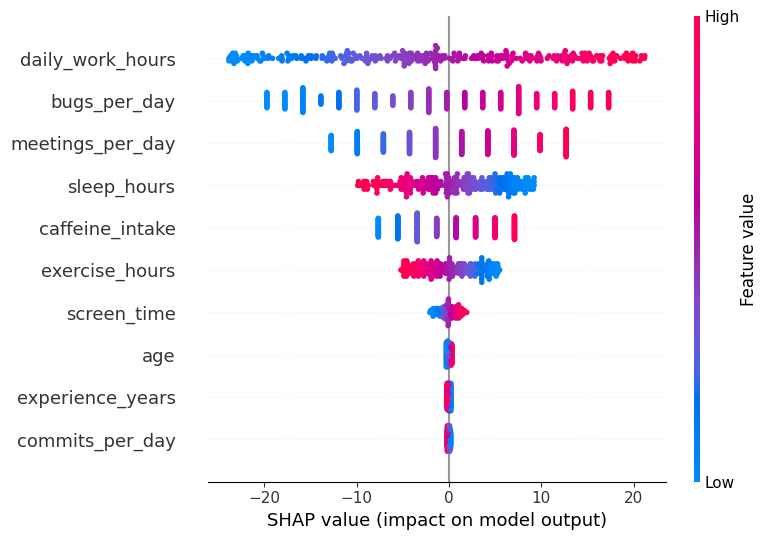

In [3]:
from sklearn.inspection import permutation_importance

svr_model = joblib.load('SVM/svr_stress_model_optimized.pkl')

# 1. Feature Importances (Permutation method for SVM)
result_svr = permutation_importance(svr_model, X_scaled_df, y, n_repeats=5, random_state=42)
plt.figure(figsize=(10, 6))
sns.barplot(x=result_svr.importances_mean, y=feature_names, palette="mako")
plt.title("SVR - Permutation Feature Importances")
plt.xlabel("Mean Importance Score")
plt.ylabel("Features")
plt.show()

# 2. SHAP Values specifically for our final elected model (SVR)
print("Calculating SHAP values for SVR... (This may take a moment)")
# Using KernelExplainer on a subset to save time
X_sample = shap.sample(X_scaled_df, 100)
explainer_svr = shap.KernelExplainer(svr_model.predict, X_sample)
shap_values_svr = explainer_svr.shap_values(X_scaled_df.iloc[:300])

shap.summary_plot(shap_values_svr, X_scaled_df.iloc[:300])

## 3. TabNet Regressor

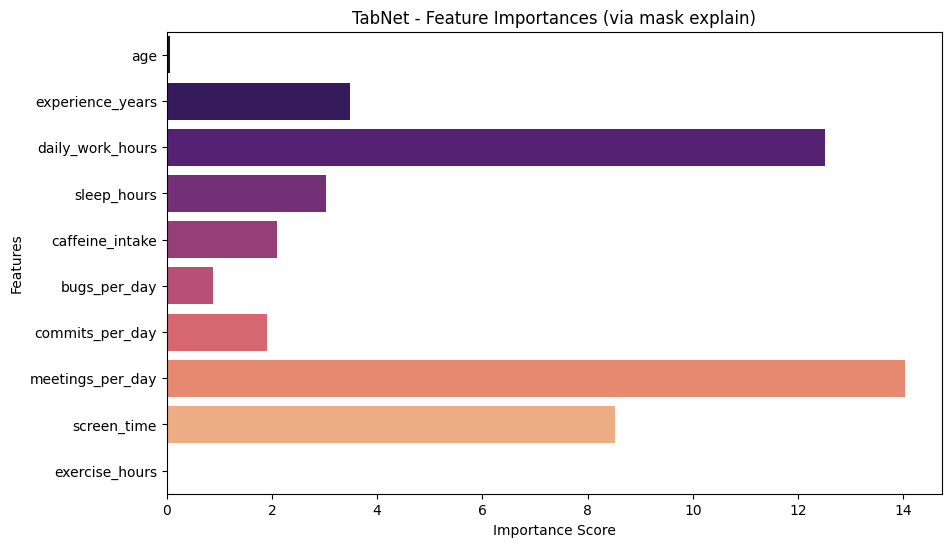

In [4]:
tabnet_model = TabNetRegressor()
tabnet_model.load_model('TabNet/tabnet_stress_model_optimized.zip')

explain_matrix, masks = tabnet_model.explain(X_scaled_df.values.astype(np.float32))
feature_importances = explain_matrix.mean(axis=0)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_names, palette="magma")
plt.title("TabNet - Feature Importances (via mask explain)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()